# **EXPLORATORY DATA ANALYSIS (EDA) TOP 100 AI TOOLS 2026**



---
Nama : Farah Hikmatul Maula

NIM  : 2509116099

Sistem Informasi C


---



Tujuan dari analisis ini yaitu mencari tahu tren ai tools dari waktu ke waktu dan faktor mempengaruhi penggunaan ai tools serta mengidentifikasi pengguanaan kategori ai tools terbanyak.

# 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Data

In [ ]:
path = "/content/drive/MyDrive/AVD/top100_ai_tools_2026.csv"
df = pd.read_csv(path)

df

,Rank,Tool_Name,Primary_Category,Sub_Category,Pricing_Model,Starting_Price_USD,Monthly_Traffic_Est,User_Rating,Agentic_Capability_Score,API_Available,Release_Year,Active_Users_Est,Description
0,1,ChatGPT,Conversational AI,General Assistant,Freemium,20.00,1800000000,4.80,9.50,Yes,2022,180000000,"OpenAI's flagship conversational AI for text, ..."
1,2,Gemini,Conversational AI,Multimodal AI,Freemium,19.99,500000000,4.70,9.30,Yes,2023,90000000,Google's multimodal AI integrated with Google ...
2,3,Canva AI,Image Generation,Design Assistant,Freemium,15.00,500000000,4.60,6.00,Yes,2023,170000000,AI design tools integrated in Canva
3,4,Character.AI,Conversational AI,Roleplay & Chat,Freemium,9.99,300000000,4.30,6.00,No,2022,20000000,AI characters for entertainment and roleplay
4,5,Claude,Conversational AI,General Assistant,Freemium,20.00,200000000,4.80,9.40,Yes,2023,50000000,Anthropic's safety-focused AI assistant with l...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Koral Bot,Research & Search,Market Research,Paid,196.25,114463,4.10,6.08,No,2023,38201,AI research assistant for faster knowledge dis...
496,497,Quill Flow,HR & Recruiting,Employee Onboarding,Paid,71.45,101182,4.18,7.39,Yes,2023,3464,AI recruitment and HR automation platform
497,498,Cipher GPT,Legal AI,Legal Research,Paid,414.84,88779,4.38,7.20,Yes,2023,18600,"AI platform for legal research, drafting, and ..."
498,499,Quill GPT,HR & Recruiting,Employee Onboarding,Paid,84.36,80270,4.22,7.35,Yes,2021,14974,AI recruitment and HR automation platform


Sebelum memulai analisis kita melakukan impor library dan memuad file top 100 ai tools untuk analisi dan visualisasi data.

# 3. Cek Struktur dan Tipe Data

In [ ]:
df.info()

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Rank                      500 non-null    int64  
 1   Tool_Name                 500 non-null    object 
 2   Primary_Category          500 non-null    object 
 3   Sub_Category              500 non-null    object 
 4   Pricing_Model             500 non-null    object 
 5   Starting_Price_USD        500 non-null    float64
 6   Monthly_Traffic_Est       500 non-null    int64  
 7   User_Rating               500 non-null    float64
 8   Agentic_Capability_Score  500 non-null    float64
 9   API_Available             500 non-null    object 
 10  Release_Year              500 non-null    int64  
 11  Active_Users_Est          500 non-null    int64  
 12  Description               500 non-null    object 
dtypes: float64(3), int64(4), object(6)
memory usage: 50.9+ KB


Index(['Rank', 'Tool_Name', 'Primary_Category', 'Sub_Category',
       'Pricing_Model', 'Starting_Price_USD', 'Monthly_Traffic_Est',
       'User_Rating', 'Agentic_Capability_Score', 'API_Available',
       'Release_Year', 'Active_Users_Est', 'Description'],
      dtype='object')

Pada bagian ini kita dapat melihat dan memastikan nama kolom, tipe data dan apakah ada missing value.

# 4. Parsing Tahun Rilis Menjadi Datetime

Pada kolom `Release_Year` (tahun) tipe datanya masih berupa integer. Kita ubah menjadi `datetime` dalam `year` agar lebih mudah dianalisis secara temporal.


In [ ]:
# Parsing kolom release_year
df["datetime"] = pd.to_datetime(
    df["Release_Year"],
    format="%Y",
    errors="coerce"
)

# Ekstrak fitur tahun
df["year"] = df["datetime"].dt.year

# Cek hasil parsing
df[["year"]].head()

,year
0,2022
1,2023
2,2023
3,2022
4,2023


# 5. Statistik Deskriptif Dasar

In [ ]:
df.describe(include='all')

,Rank,Tool_Name,Primary_Category,Sub_Category,Pricing_Model,Starting_Price_USD,Monthly_Traffic_Est,User_Rating,Agentic_Capability_Score,API_Available,Release_Year,Active_Users_Est,Description,datetime,year
count,500.000000,500,500,500,500,500.000000,5.000000e+02,500.000000,500.000000,500,500.000000,5.000000e+02,500,500,500.000000
unique,NaN,500,22,162,5,NaN,NaN,NaN,NaN,2,NaN,NaN,185,NaN,NaN
top,NaN,Cipher Flow,Developer Tools,Homework Helper,Paid,NaN,NaN,NaN,NaN,Yes,NaN,NaN,AI writing tool for generating high-quality co...,NaN,NaN
freq,NaN,1,58,14,252,NaN,NaN,NaN,NaN,397,NaN,NaN,28,NaN,NaN
mean,250.500000,NaN,NaN,NaN,NaN,61.616940,1.189889e+07,4.285060,6.610580,NaN,2022.138000,1.948661e+06,NaN,2022-02-20 07:09:07.200000256,2022.138000
min,1.000000,NaN,NaN,NaN,NaN,0.000000,6.587800e+04,3.800000,2.000000,NaN,2009.000000,3.510000e+02,NaN,2009-01-01 00:00:00,2009.000000
25%,125.750000,NaN,NaN,NaN,NaN,12.000000,6.152182e+05,4.157500,5.600000,NaN,2021.000000,3.296050e+04,NaN,2021-01-01 00:00:00,2021.000000
50%,250.500000,NaN,NaN,NaN,NaN,24.000000,1.148314e+06,4.290000,6.630000,NaN,2023.000000,8.589150e+04,NaN,2023-01-01 00:00:00,2023.000000
75%,375.250000,NaN,NaN,NaN,NaN,71.572500,3.000000e+06,4.400000,7.610000,NaN,2024.000000,2.620055e+05,NaN,2024-01-01 00:00:00,2024.000000
max,500.000000,NaN,NaN,NaN,NaN,1000.000000,1.800000e+09,4.800000,9.940000,NaN,2025.000000,1.800000e+08,NaN,2025-01-01 00:00:00,2025.000000


Tabel ini menjelaskan secara ringkas di setiap kolom numerik seperti jumlah data, rata-rata, standar deviasi, nilai minimum, kuartil, dan maksimum.

# 6. Mengecek Missing Value

In [ ]:
# Hitung jumlah missing values per kolom
missing = df.isna().sum()
missing

# Persentase missing values
missing_pct = df.isna().mean() * 100
missing_pct

,0
Rank,0.0
Tool_Name,0.0
Primary_Category,0.0
Sub_Category,0.0
Pricing_Model,0.0
Starting_Price_USD,0.0
Monthly_Traffic_Est,0.0
User_Rating,0.0
Agentic_Capability_Score,0.0
API_Available,0.0


Berdasarkan pengecekan diatas tidak terdapat kolom yang datanya missing value.

# 7. Distribusi Rating dan Kategori AI Tools

## 7.1 Histogram Rating

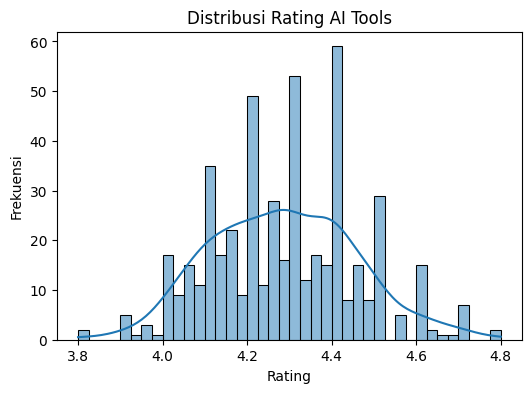

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(df["User_Rating"], bins=40, kde=True)
plt.title("Distribusi Rating AI Tools")
plt.xlabel("Rating")
plt.ylabel("Frekuensi")
plt.show()

Pada plot histogram ini menunjukkan persebaran rating pengguna pada berbagai macam AI tools dalam dataset.

Sebagian besar rating ada di 4.1 sampai 4.5 hal ini menujjukan bahwa kebanyakan AI tools mempunyai penilaian yang cukup tinggi.

## 7.2 Histogram Kategori AI

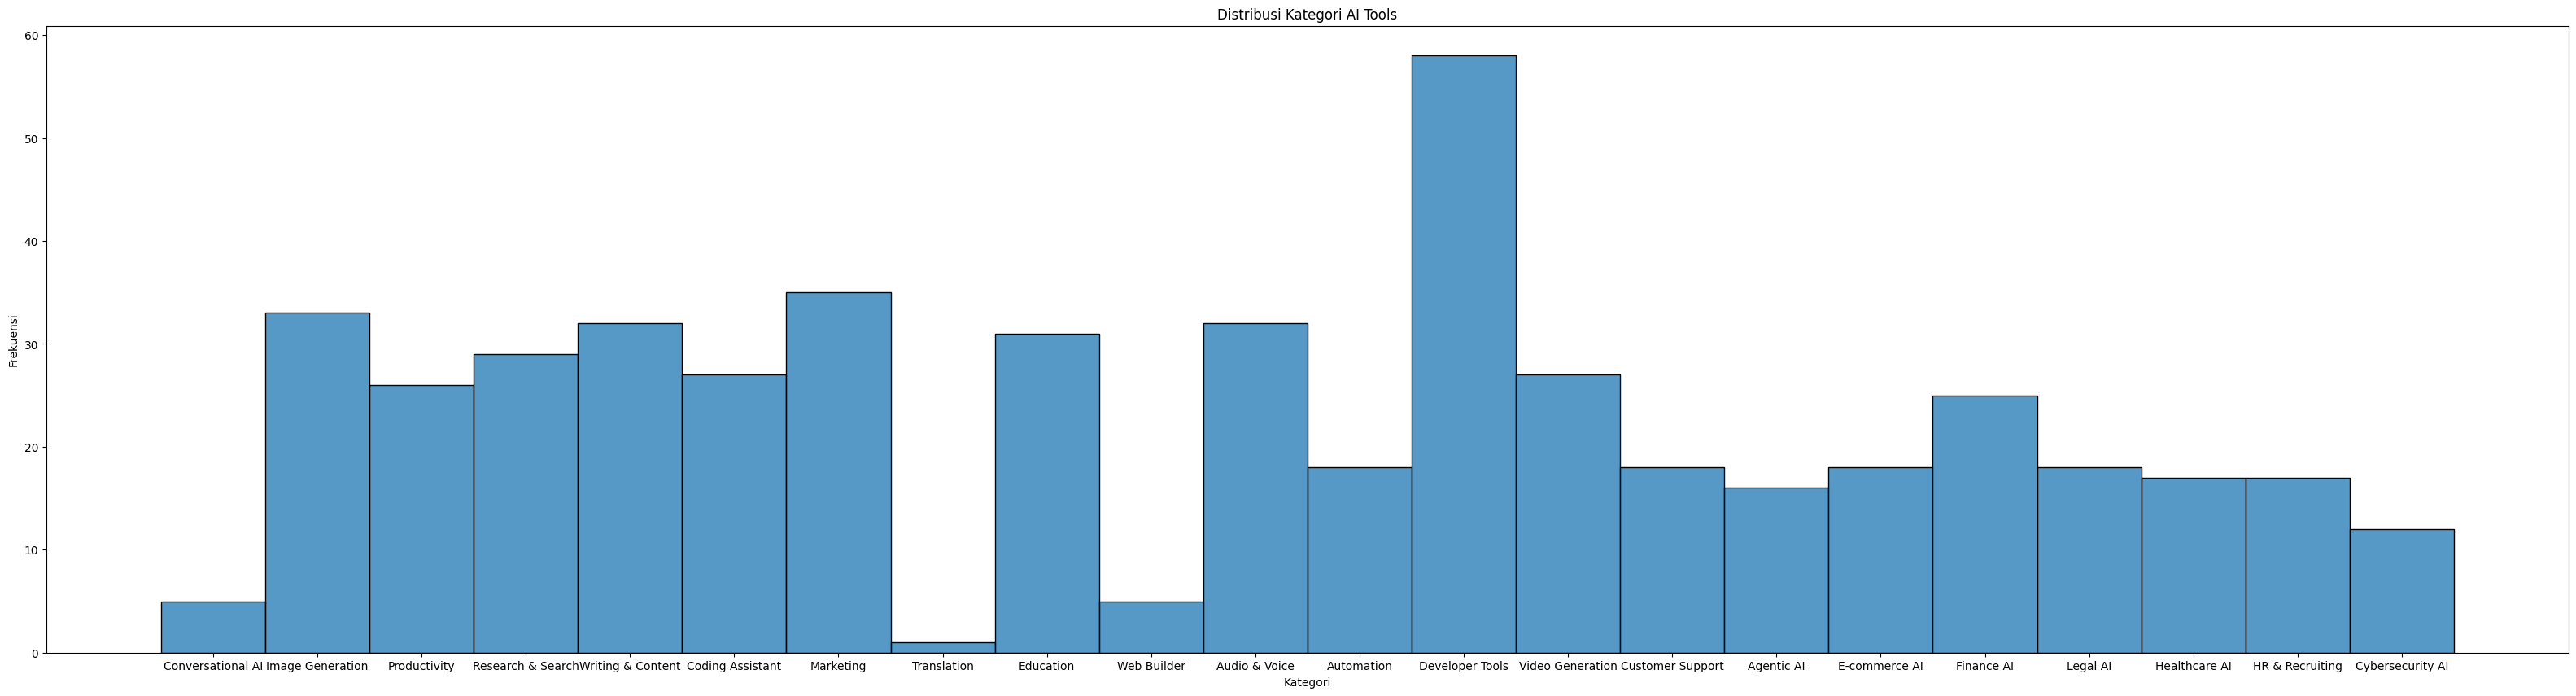

In [ ]:
plt.figure(figsize=(40, 10))
sns.histplot(df["Primary_Category"], bins=40, kde=False)
plt.title("Distribusi Kategori AI Tools")
plt.xlabel("Kategori")
plt.ylabel("Frekuensi")
plt.show()

Grafik di atas menunjukkan jumlah tools AI yang digunakan pada setiap kategori. Terlihat beberapa kategori mempunyai jumlah tools yang lebih banyak yang artinya menunjukkan perkembangan AI yang paling populer.

# 8. Sebaran Kemampuan AI Tools

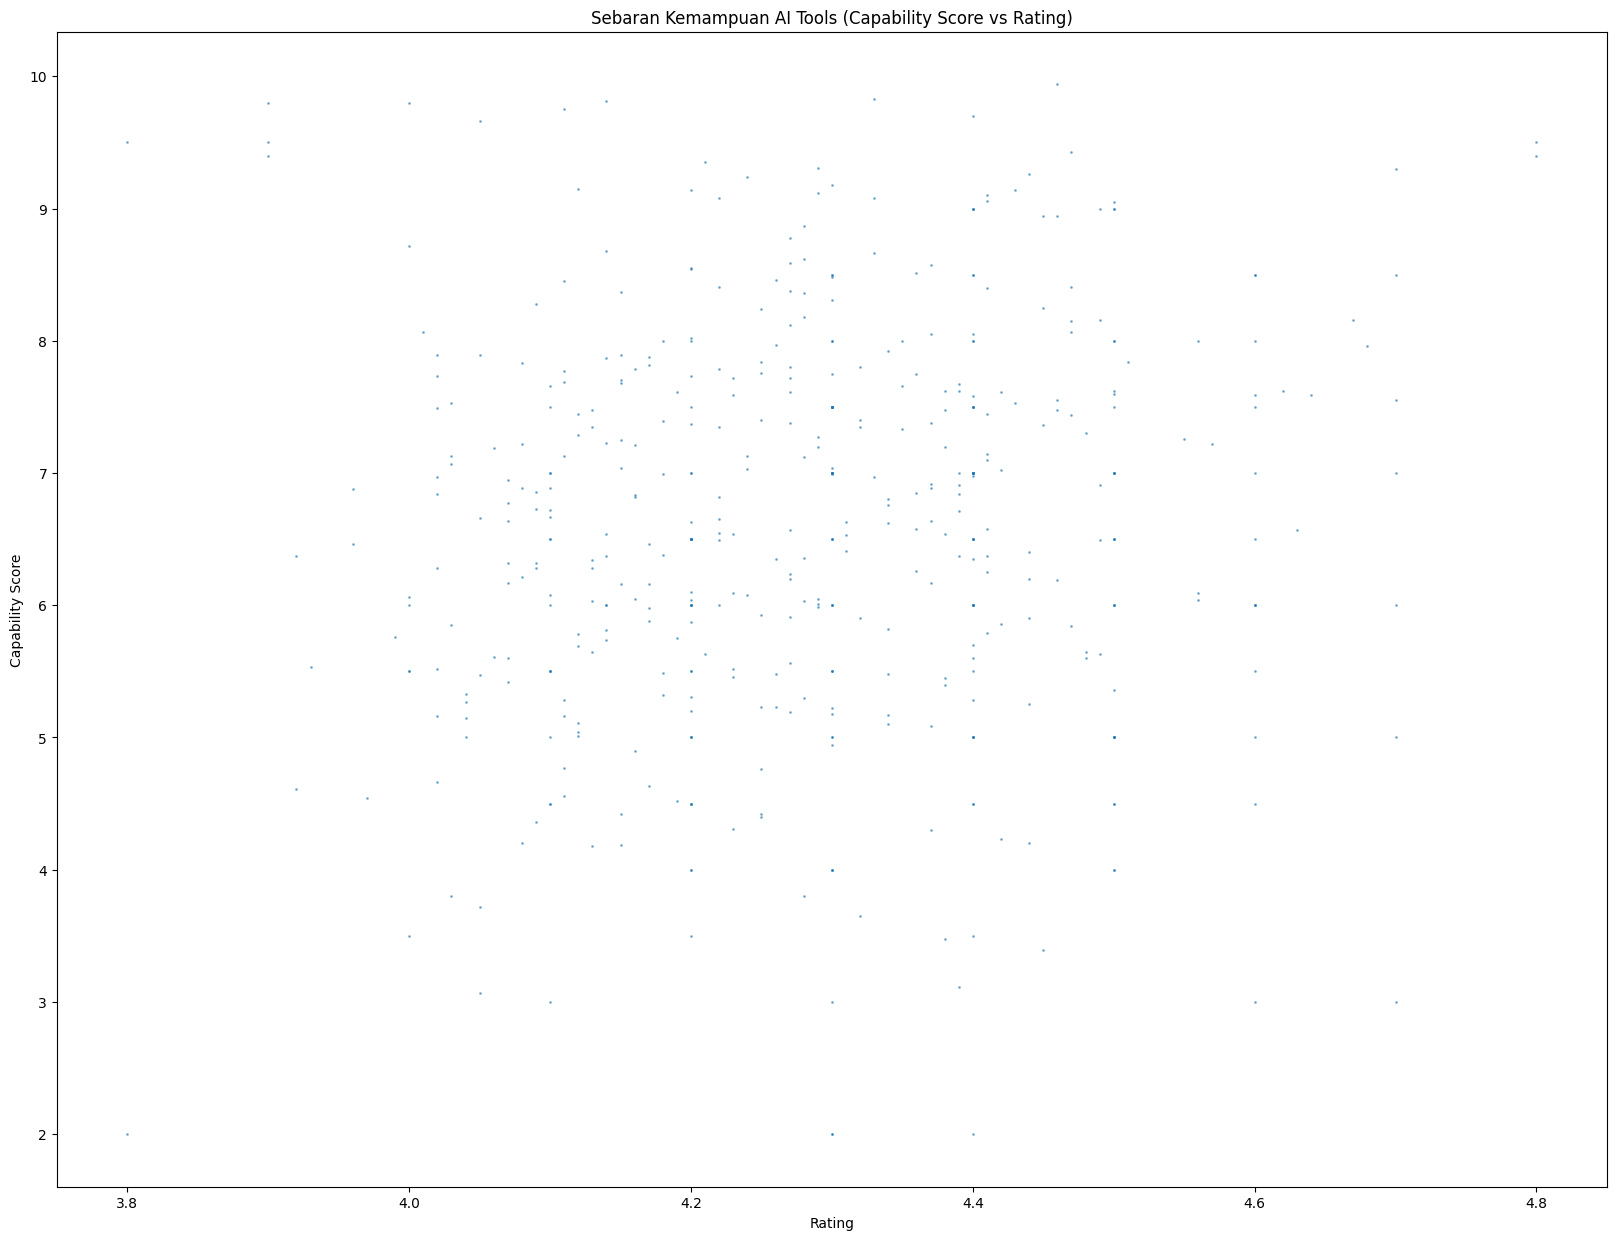

In [ ]:
plt.figure(figsize=(20, 15))
plt.scatter(df["User_Rating"], df["Agentic_Capability_Score"], s=1, alpha=0.5)
plt.title("Sebaran Kemampuan AI Tools (Capability Score vs Rating)")
plt.xlabel("Rating")
plt.ylabel("Capability Score")
plt.show()

Scatter plot ini menunjukkan hubungan antara rating pengguna dan capability score dari AI tools.

# 9. Analisis Temporal

### 9.1 Jumlah Traffic AI per Tahun

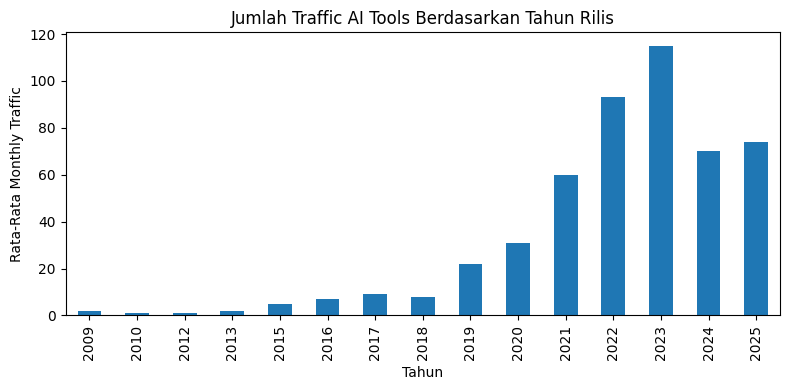

In [ ]:
jumlah_traffic = df.groupby("Release_Year")["Monthly_Traffic_Est"].count()

plt.figure(figsize=(8, 4))
jumlah_traffic.plot(kind="bar")
plt.title("Jumlah Traffic AI Tools Berdasarkan Tahun Rilis")
plt.xlabel("Tahun")
plt.ylabel("Rata-Rata Monthly Traffic")
plt.tight_layout()
plt.show()

Grafik di atas menunjukkan jumlah pengguna yang datang menggunakan AI tools berdasarkan tahun rilisnya. Jumlah trffic mulai 2019 mengalami peningkatan yang artinya meningkatnya minat dan adopsi teknologi AI.

### 9.2 Rata-Rata Traffic AI

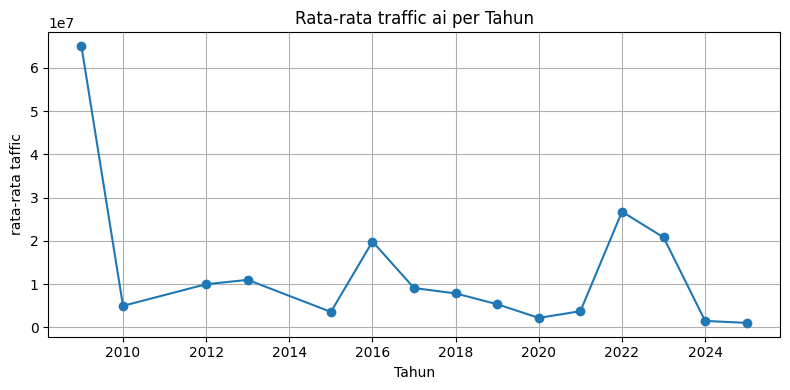

In [ ]:
Traffic_per_tahun = df.groupby("Release_Year")["Monthly_Traffic_Est"].mean()

plt.figure(figsize=(8, 4))
Traffic_per_tahun.plot(marker="o")
plt.title("Rata-rata traffic ai per Tahun")
plt.xlabel("Tahun")
plt.ylabel("rata-rata taffic")
plt.grid(True)
plt.tight_layout()
plt.show()

Grafik menunjukkan rata-rata traffic AI tools berdasarkan tahun rilis. Terlihat bahwa rata-rata traffic mengalami perubahan dari tahun ke tahun.

9.3 Jumlah Rating Pada Traffic AI per Tahun

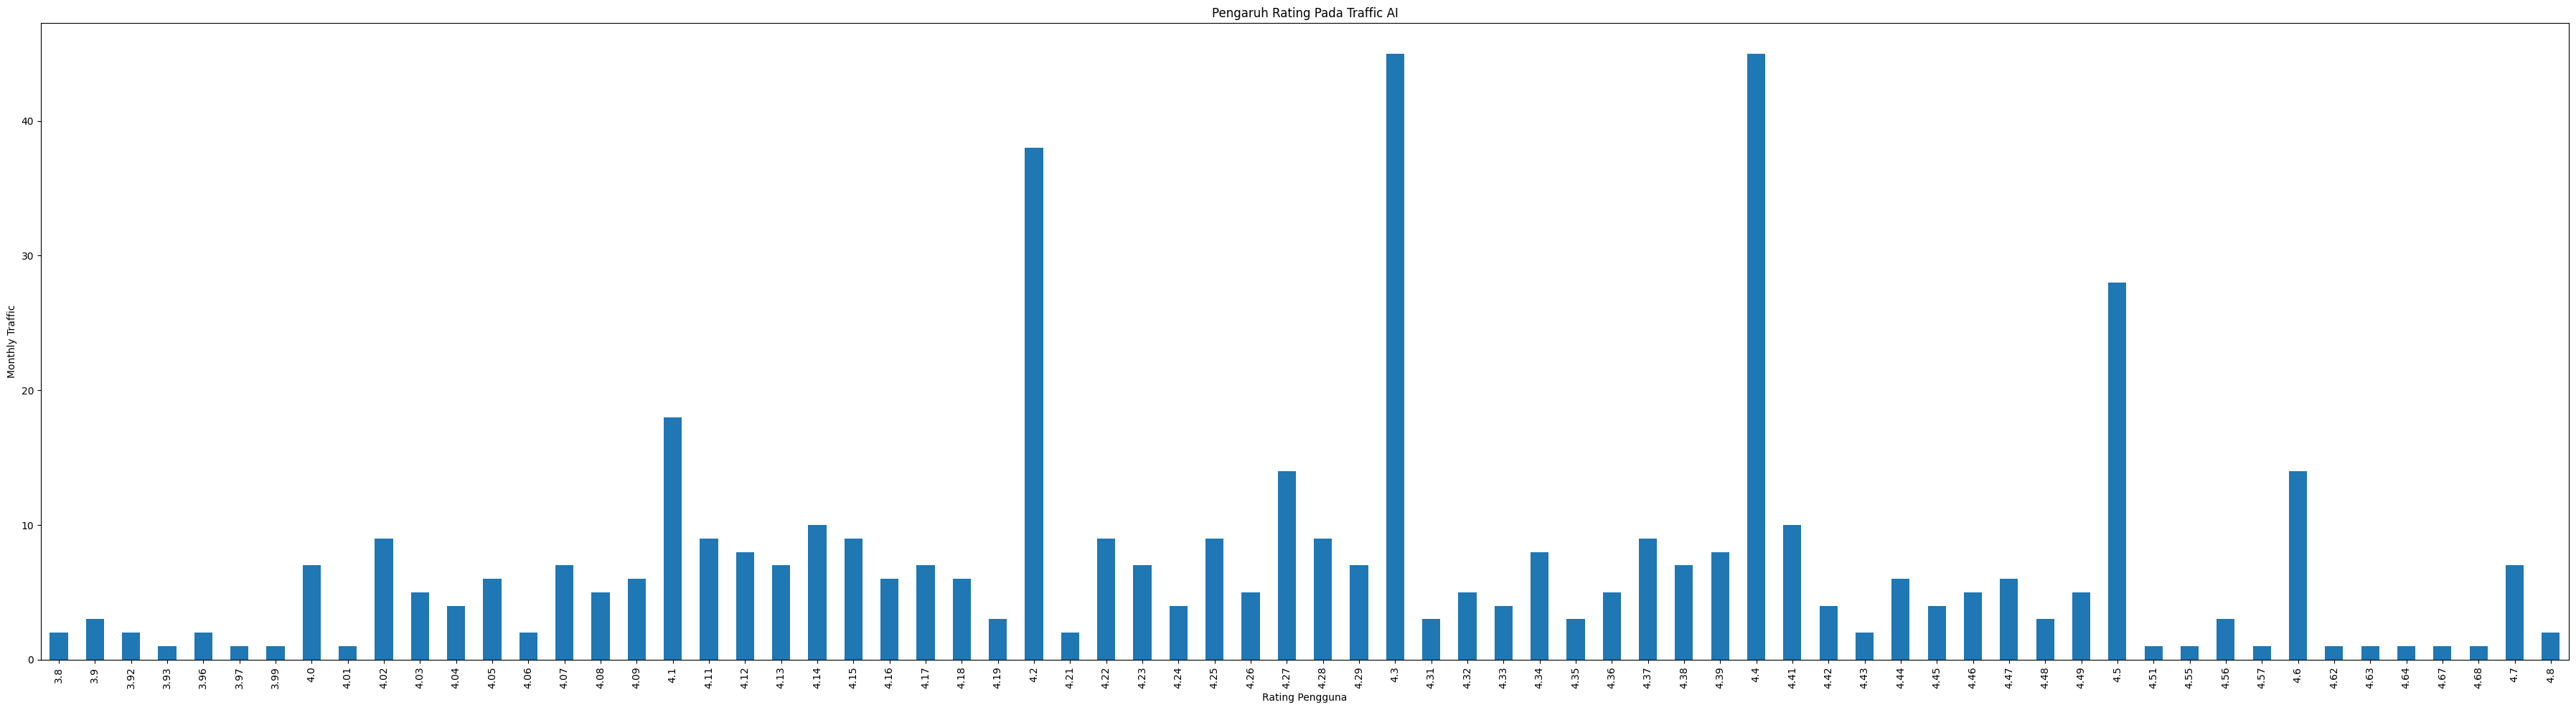

In [ ]:
rating = df.groupby("User_Rating")["Monthly_Traffic_Est"].count()

plt.figure(figsize=(36, 10))
rating.plot(kind="bar")
plt.title("Pengaruh Rating Pada Traffic AI")
plt.xlabel("Rating Pengguna")
plt.ylabel("Monthly Traffic")
plt.tight_layout()
plt.show()

Plot ini digunakan untuk melihat hubungan antara rating dan traffic kunjungan orang setiap bulan.

# 10. Hubungan Rating dan Kategori AI Tools

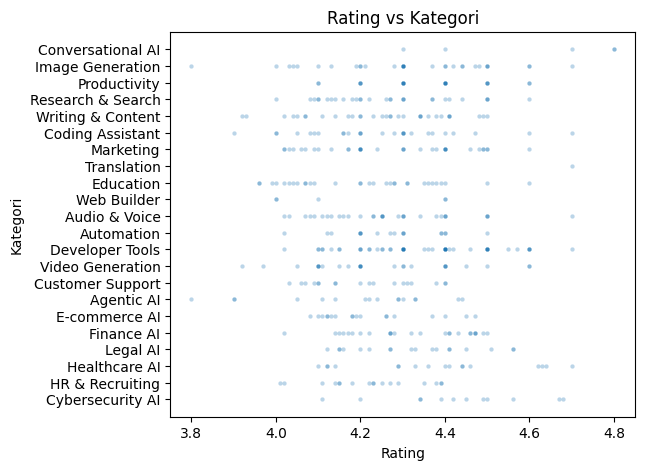

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="User_Rating", y="Primary_Category", alpha=0.3, s=10)
plt.title("Rating vs Kategori")
plt.xlabel("Rating")
plt.ylabel("Kategori")
plt.show()

Grafik diatas menunjukkan hubungan rating pengguna dan berbagai kategori AI tools. Secara umum, terlihat sebagian besar AI tools memiliki rating yang berada pada kisaran 4.0 sampai 4.5, yang artinya kebanyakan tools dinilai cukup baik oleh pengguna.

# 11. Korelasi Kolom Numerik

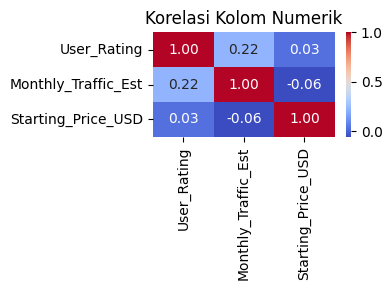

In [ ]:
num_cols = ["User_Rating", "Monthly_Traffic_Est", "Starting_Price_USD"]
corr = df[num_cols].corr()

plt.figure(figsize=(4, 3))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Kolom Numerik")
plt.tight_layout()
plt.show()

Heatmap pada korelasi ini memperlihatkan hubungan linear antara fitur numerik utama.

# 12. Analisis Spasial Berdasarkan Tools AI

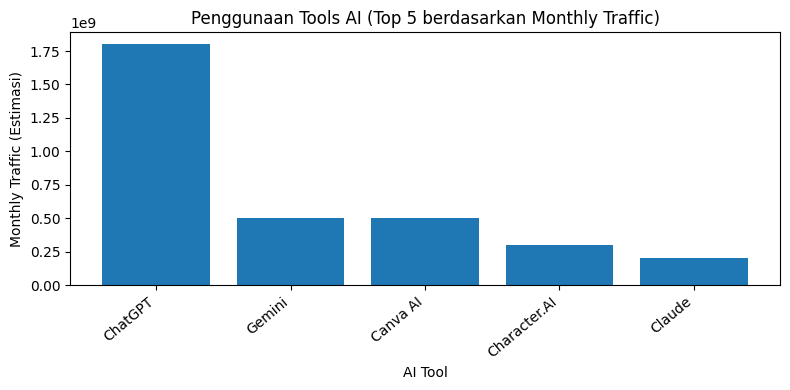

      Tool_Name  Monthly_Traffic_Est
0       ChatGPT           1800000000
1        Gemini            500000000
2      Canva AI            500000000
3  Character.AI            300000000
4        Claude            200000000


In [ ]:
top_tools_traffic = df.nlargest(5, 'Monthly_Traffic_Est')

plt.figure(figsize=(8, 4))
plt.bar(top_tools_traffic['Tool_Name'], top_tools_traffic['Monthly_Traffic_Est'])
plt.title("Penggunaan Tools AI (Top 5 berdasarkan Monthly Traffic)")
plt.xlabel("AI Tool")
plt.ylabel("Monthly Traffic (Estimasi)")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

print(top_tools_traffic[['Tool_Name', 'Monthly_Traffic_Est']])

Gambar gambar diatas menunjukkan  perkiraan jumlah pengunjung bulanan (monthly traffic) pada 5 tools AI yang paling populer. Secara keseluruhan, grafik ini menjelaskan bahwa ChatGPT jauh lebih unggul dalam  penggunaan dibandingkan tools AI lainnya.

# 13. Statistik Kunjungan Penggunaan Berdasarkan Tools AI

In [ ]:
top5_names = top_regions.index[:5]
stats_region = df[df["Tool_Name"].isin(top5_names)].groupby("Tool_Name")["Monthly_Traffic_Est"].describe()
stats_region

,count,mean,std,min,25%,50%,75%,max
Tool_Name,,,,,,,,
Canva AI,1.0,5.000000e+08,NaN,5.000000e+08,5.000000e+08,5.000000e+08,5.000000e+08,5.000000e+08
ChatGPT,1.0,1.800000e+09,NaN,1.800000e+09,1.800000e+09,1.800000e+09,1.800000e+09,1.800000e+09
Cipher Flow,1.0,6.587800e+04,NaN,6.587800e+04,6.587800e+04,6.587800e+04,6.587800e+04,6.587800e+04
Cosmo Studio,1.0,1.717500e+05,NaN,1.717500e+05,1.717500e+05,1.717500e+05,1.717500e+05,1.717500e+05
Gemini,1.0,5.000000e+08,NaN,5.000000e+08,5.000000e+08,5.000000e+08,5.000000e+08,5.000000e+08


Tabel diatas menampilkan tabel statistik deskriptif dari beberapa tools AI berdasarkan estimasi jumlah kunjungan bulanan (monthly traffic). Bisa dilihat ChatGPT memiliki nilai rata-rata kunjungan tertinggi sekitar 1,8 miliar, sehingga menjadi yang paling dominan dibandingkan tools lainnya.

# 14. EDA Kolom Numerik AI Tools (Traffic, User, Rating, Capability Score)

In [ ]:
mech_cols = ["Monthly_Traffic_Est", "Active_Users_Est", "User_Rating", "Agentic_Capability_Score"]

# Deskripsi statistik parameter mekanisme sumber
df[mech_cols].describe()

,Monthly_Traffic_Est,Active_Users_Est,User_Rating,Agentic_Capability_Score
count,5.000000e+02,5.000000e+02,500.000000,500.000000
mean,1.189889e+07,1.948661e+06,4.285060,6.610580
std,8.868521e+07,1.246835e+07,0.171419,1.494926
min,6.587800e+04,3.510000e+02,3.800000,2.000000
25%,6.152182e+05,3.296050e+04,4.157500,5.600000
50%,1.148314e+06,8.589150e+04,4.290000,6.630000
75%,3.000000e+06,2.620055e+05,4.400000,7.610000
max,1.800000e+09,1.800000e+08,4.800000,9.940000


Tabel diatas menunjukkan ringkasan statistik pada beberapa kolom numerik. Kolom yang dipakai yaitu Monthly_Traffic_Est, Active_Users_Est, User_Rating, dan Agentic_Capability_Score.

#15. Distribusi Monthly_Traffic_Est dan User_Rating

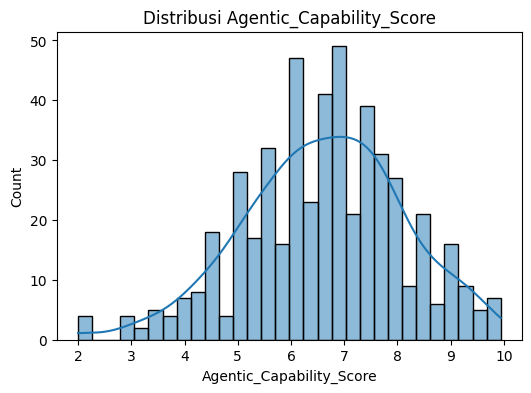

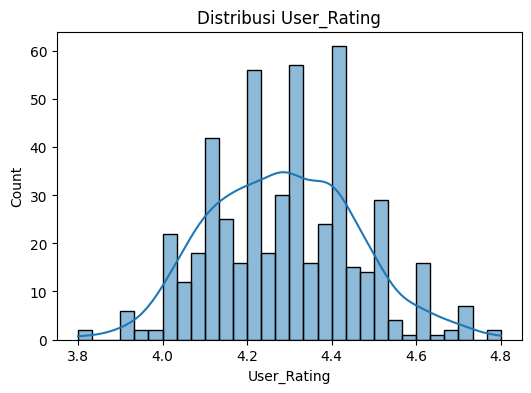

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Agentic_Capability_Score"].dropna(), bins=30, kde=True)
plt.title("Distribusi Agentic_Capability_Score")
plt.xlabel("Agentic_Capability_Score")
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(df["User_Rating"].dropna(), bins=30, kde=True)
plt.title("Distribusi User_Rating")
plt.xlabel("User_Rating")
plt.show()

Plot ini menggambarkan sebaran nilai **Agentic Capability Score** dan **User Rating** pada tools AI, menunjukkan bahwa sebagian besar nilai kemampuan agentic berada pada tingkat menengah, penilaian pengguna cenderung tinggi.


# 16. Filter Penggunaan Tools AI berdasarkan Tahun Rilisnya.

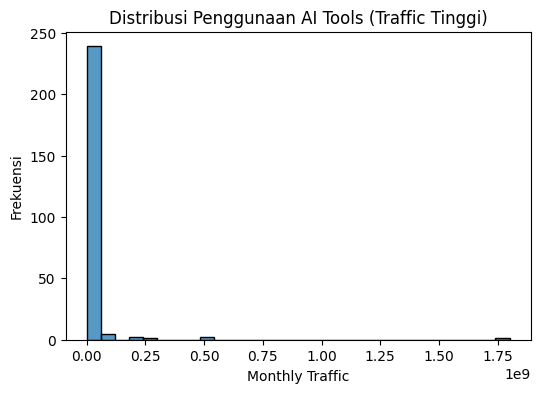

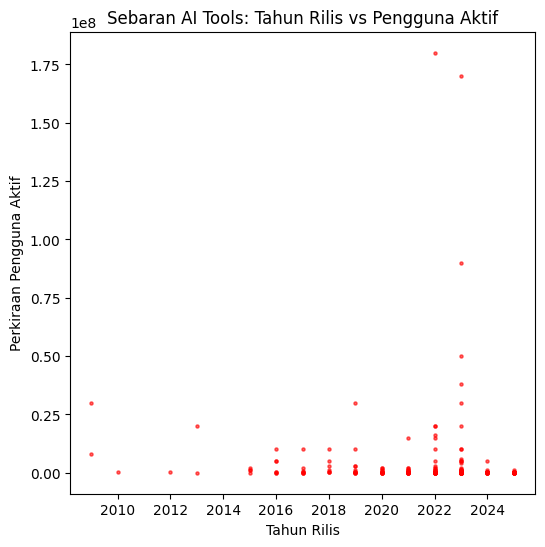

In [ ]:
big_ai = df[df["Monthly_Traffic_Est"] >= df["Monthly_Traffic_Est"].median()]

# Distribusi penggunaan ai
plt.figure(figsize=(6, 4))
sns.histplot(big_ai["Monthly_Traffic_Est"], bins=30)
plt.title("Distribusi Penggunaan AI Tools (Traffic Tinggi)")
plt.xlabel("Monthly Traffic")
plt.ylabel("Frekuensi")
plt.show()

# Sebaran lokasi gempa besar
plt.figure(figsize=(6, 6))
plt.scatter(big_ai["Release_Year"], big_ai["Active_Users_Est"], s=5, alpha=0.6, c="red")
plt.title("Sebaran AI Tools: Tahun Rilis vs Pengguna Aktif")
plt.xlabel("Tahun Rilis")
plt.ylabel("Perkiraan Pengguna Aktif")
plt.show()

Dengan memfokuskan pada AI tools dengan traffic tinggi, kita dapat melihat pada kedua grafik diatas  bahwa distribusi penggunaannya lebih tidak merata yang didominasi  sedikit tools dengan traffic sangat besar, serta sebaran menunjukkan bahwa tools yang lebih baru cenderung memiliki jumlah pengguna aktif yang lebih tinggi dibandingkan yang lebih lama.


# 17. Ringkasan

Dalam notebook ini, kita telah:

* Memuat dan memeriksa struktur data top 100 AI tools.
* Mengonversi tahun rilis menjadi format datetime untuk analisis temporal.
* Melihat distribusi rating pengguna dan kategori AI tools.
* Menganalisis sebaran kemampuan AI dalam menjalankan tugas (Agentic Capability Score) terhadap rating.
* Mengeksplorasi tren penggunaan AI tools dari waktu ke waktu berdasarkan traffic dan tahun rilis.
* Menganalisis hubungan antara rating, traffic, dan kategori AI tools.
* Menghitung dan memvisualisasikan korelasi antar variabel numerik.
* Mengidentifikasi AI tools dengan penggunaan tertinggi berdasarkan monthly traffic est.
* Melihat statistik deskriptif dari tools AI terpopuler.
* Mengeksplorasi distribusi variabel numerik utama seperti jumlah pengunjung, pengguna aktif, rating, dan agentic capability score.
* Merangkum AI tools dengan traffic tinggi untuk melihat pola penggunaan dan tren adopsinya.
